--- Starting Data-Driven Model Calibration Study ---
Integrating reference solution (Ns = 10000000)...
Reference PDF-TLPP (dynamic frame) created.
Starting comparison runs...
Running trial for Ns = 1000000...
Running HiGHS 1.11.0 (git hash: 364c83a51e): Copyright (c) 2025 HiGHS under MIT licence terms
LP   has 2048 rows; 1048000 cols; 2096000 nonzeros
Coefficient ranges:
  Matrix [1e+00, 1e+00]
  Cost   [1e-02, 5e+01]
  Bound  [0e+00, 0e+00]
  RHS    [1e-07, 1e-02]
Presolving model
2048 rows, 1048000 cols, 2096000 nonzeros  0s
Dependent equations search running on 2048 equations with time limit of 1000.00s
Dependent equations search removed 1 rows and 1048 nonzeros in 1.79s (limit = 1000.00s)
2047 rows, 1048000 cols, 2094952 nonzeros  3s
Presolve : Reductions: rows 2047(-1); columns 1048000(-0); elements 2094952(-1048)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 2047(2) 3s

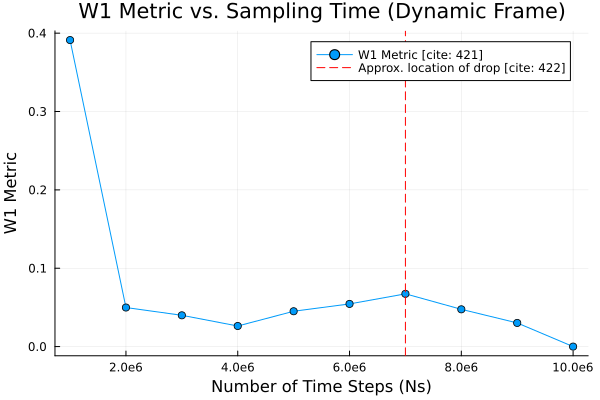

In [41]:
using DifferentialEquations
using StatsBase
using OptimalTransport
using Plots
using HiGHS  
using LinearAlgebra

## 1. LORENZ SYSTEM DEFINITION
# Based on Section III.A of the paper

# Define the Lorenz equations
function lorenz!(du, u, p, t)
    σ, β, ρ = p
    du[1] = σ * (u[2] - u[1])      # dx/dt [cite: 313]
    du[2] = u[1] * (ρ - u[3]) - u[2] # dy/dt [cite: 313]
    du[3] = u[1] * u[2] - β * u[3]   # dz/dt [cite: 313]
end

# Set parameters to the paper's baseline values [cite: 341]
σ = 10.0
β = 2.667
ρ = 28.0
p = (σ, β, ρ)

# Set initial position [cite: 341]
u0 = [10.0, 10.0, 10.0]

# Set the fixed time step [cite: 342]
dt = 5e-3

## 2. HELPER FUNCTIONS

"""
    create_pdf_tlpp(x_signal)

Creates a 2D time-lagged phase portrait (TLPP) from a 1D signal,
bins it into a 50x50 grid, and normalizes it to a PDF.

This function uses the "dynamic frame" method, where the
histogram bounds are set by the min/max of the *current* signal.
"""
function create_pdf_tlpp(x_signal)
    # Time lag τ = 20 time steps 
    τ = 20
    n = length(x_signal)

    # Create the 2D time-lagged data: (X(t), X(t-τ))
    # We use the x-signal as the embedded signal [cite: 352]
    x_t = x_signal[τ+1:end]
    x_t_minus_tau = x_signal[1:end-τ]

    # Dynamic Frame: Calculate bounds from *this specific* signal 
    # This causes the bounds to change, e.g., from ±21.7 to ±21.8 [cite: 418]
    min_val = floor(min(minimum(x_t), minimum(x_t_minus_tau)))
    max_val = ceil(max(maximum(x_t), maximum(x_t_minus_tau)))
    
    # Use 50x50 grid 
    bins = (range(min_val, stop=max_val, length=51), 
            range(min_val, stop=max_val, length=51))

    # Create the 2D histogram
    h = fit(Histogram, (x_t, x_t_minus_tau), bins)
    
    # Normalize to get the PDF
    pdf = normalize(h)
    return pdf
end

"""
    get_dist_data(pdf)

Helper function to extract bin centers (locations) and probabilities (weights)
from a normalized 2D Histogram. This format is needed for OptimalTransport.jl.
"""
function get_dist_data(pdf::Histogram{<:Real, 2})
    weights = pdf.weights
    edges_x, edges_y = pdf.edges

    # Calculate bin centers
    centers_x = (edges_x[1:end-1] .+ edges_x[2:end]) ./ 2
    centers_y = (edges_y[1:end-1] .+ edges_y[2:end]) ./ 2

    # Store points and their probabilities
    points = Vector{Float64}[]
    probs = Float64[]
    
    for (i, w) in enumerate(weights)
        if w > 0.0 # Only include bins with non-zero probability
            idx = CartesianIndices(weights)[i]
            push!(points, [centers_x[idx[1]], centers_y[idx[2]]])
            push!(probs, w)
        end
    end
    
    # Return as a (2 x N) matrix of points and a (N) vector of probabilities
    return hcat(points...), probs
end

"""
    calculate_w1(pdf_ref, pdf_trial)

Calculates the First Wasserstein Metric (W1), or Earth Mover's Distance,
between two 2D probability distributions (PDF-TLPPs).
"""
function calculate_w1(pdf_ref, pdf_trial)
    # Extract locations and weights for both PDFs
    points_ref, probs_ref = get_dist_data(pdf_ref)
    points_trial, probs_trial = get_dist_data(pdf_trial)

    # Re-normalize the probability vectors
    norm_probs_ref = probs_ref ./ norm(probs_ref, 1)
    norm_probs_trial = probs_trial ./ norm(probs_trial, 1)
    
    # Calculate the cost matrix: C[i, j] = Euclidean distance(point_i, point_j)
    cost_matrix = [sqrt((points_ref[1,i] - points_trial[1,j])^2 + 
                       (points_ref[2,i] - points_trial[2,j])^2)
                   for i in 1:size(points_ref, 2), j in 1:size(points_trial, 2)]

    # --- START OF FIX ---

    # 1. Calculate the optimal transport PLAN (this is a Matrix)
    transport_plan = emd(Float64.(norm_probs_ref), Float64.(norm_probs_trial), cost_matrix, HiGHS.Optimizer())
    
    # 2. The W1 distance is the sum of (plan[i,j] * cost[i,j]) for all i,j
    w1_distance = sum(transport_plan .* cost_matrix)

    # 3. Return the distance (a Float64)
    return w1_distance
    
    # --- END OF FIX ---
end


## 3. MAIN EXPERIMENT
# Recreates the study described in Sec III.B [cite: 347-352]

println("--- Starting Data-Driven Model Calibration Study ---")

# 1. Generate the Reference Solution
Ns_ref = 10_000_000 # Reference is 10^7 time steps [cite: 349]
tspan_ref = (0.0, Ns_ref * dt)
prob_ref = ODEProblem(lorenz!, u0, tspan_ref, p)

println("Integrating reference solution (Ns = $Ns_ref)...")
# We use saveat=dt to ensure we get exactly Ns_ref steps
sol_ref = solve(prob_ref, Tsit5(), saveat=dt, progress=true)

# Extract the x-signal [cite: 352]
x_ref = [u[1] for u in sol_ref.u]

# Create the reference PDF-TLPP
pdf_ref = create_pdf_tlpp(x_ref)
println("Reference PDF-TLPP (dynamic frame) created.")


# 2. Run Comparison Study
# We test finite numbers of time steps from 10^6 to 10^7 [cite: 349]
Ns_values = round.(Int, 1e6:1e6:1e7)
w1_metrics = Float64[]

println("Starting comparison runs...")
for Ns_trial in Ns_values
    println("Running trial for Ns = $Ns_trial...")
    
    # We can just take a subset of the full reference solution
    # This is valid as all systems are "exactly identical" in parameters
    # and initial conditions [cite: 350]
    x_trial = x_ref[1:Ns_trial]

    # Create the trial PDF-TLPP using its *own* dynamic frame 
    pdf_trial = create_pdf_tlpp(x_trial)
    
    # Calculate W1 metric against the reference
    w1 = calculate_w1(pdf_ref, pdf_trial)
    push!(w1_metrics, w1)
    println("  W1 Metric = $w1")
end

println("Study complete.")

## 4. PLOT RESULTS
# This plot recreates the trend shown in Figure 6(c) 

p = plot(Ns_values, w1_metrics,
    title="W1 Metric vs. Sampling Time (Dynamic Frame)",
    xlabel="Number of Time Steps (Ns)",
    ylabel="W1 Metric",
    label="W1 Metric [cite: 421]",
    legend=:topright,
    marker=:circle,
    xaxis=(formatter = x -> string(x/1e6, "e6"))
)

# Highlight the discontinuous drop mentioned in the paper [cite: 422]
vline!([7e6], 
    linestyle=:dash, 
    color=:red, 
    label="Approx. location of drop [cite: 422]")

display(p)

println("Plot generated. Note: The discontinuous drop [cite: 422] is caused by the")
println("dynamic frame bounds suddenly 'locking' to the reference bounds.")

--- Generating Plot for Ns = 1,000,000 (Fig. 6a) ---
Integrating Lorenz system for 1000000 steps...
Integration complete.
Generating plot...
Plot generation complete.


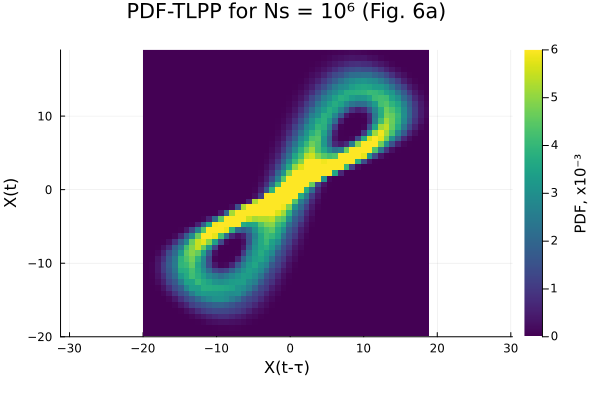

In [43]:
## 3. GENERATE DATA AND PLOT

println("--- Generating Plot for Ns = 1,000,000 (Fig. 6a) ---")

# 1. Set up and run the simulation
tspan = (0.0, Ns_trial * dt)
prob = ODEProblem(lorenz!, u0, tspan, p)

println("Integrating Lorenz system for $Ns_trial steps...")
sol = solve(prob, Tsit5(), saveat=dt, progress=true)

# 2. Extract the x-signal
x_trial = [u[1] for u in sol.u]
println("Integration complete.")

# 3. Create the PDF-TLPP
# This histogram is a PMF (Prob. Mass Function), where weights sum to 1.
pdf_1m = create_pdf_tlpp(x_trial)

# 4. Convert Mass to Density for Plotting
# To match the paper's "PDF" (Prob. Density Function) plot[cite: 1311], 
# we must convert the probability *mass* to *density*.
# Density = Mass / Bin_Area

# Get bin dimensions
bin_width_x = pdf_1m.edges[1][2] - pdf_1m.edges[1][1]
bin_width_y = pdf_1m.edges[2][2] - pdf_1m.edges[2][1]
bin_area = bin_width_x * bin_width_y

# Calculate density and scale it by 1000 to match the paper's legend [cite: 1311]
density_data = (pdf_1m.weights ./ bin_area) * 1e3

# 5. Get bin centers for the axes
x_centers = (pdf_1m.edges[1][1:end-1] .+ pdf_1m.edges[1][2:end]) ./ 2
y_centers = (pdf_1m.edges[2][1:end-1] .+ pdf_1m.edges[2][2:end]) ./ 2

# 6. Create the heatmap
println("Generating plot...")
fig6a = heatmap(x_centers, y_centers, density_data,
    title="PDF-TLPP for Ns = 10⁶ (Fig. 6a)",
    xlabel="X(t-τ)",         # [cite: 1317]
    ylabel="X(t)",         # [cite: 1307]
    colorbar_title="PDF, x10⁻³", # [cite: 1311]
    aspect_ratio=:equal,
    clims=(0, 6),          # Set color limits to match paper's legend [cite: 1311]
    c=:viridis             # You can change colormap (e.g., :jet, :hot)
)

display(fig6a)

println("Plot generation complete.")

In [1]:
module TLPPTrain

using Enzyme
using Optimisers
using Random
using LinearAlgebra

export L63Params, TLPPConfig, build_obs_tlpp, train_tlpp, simulate_series

# ------------------- Lorenz-63 -------------------
Base.@kwdef mutable struct L63Params
    σ::Float64 = 10.0
    ρ::Float64 = 28.0
    β::Float64 = 8/3
end

@inline function _f!(du, u, p::L63Params)
    x,y,z = u
    du[1] = p.σ*(y - x)
    du[2] = x*(p.ρ - z) - y
    du[3] = x*y - p.β*z
    return nothing
end

@inline function _rk4!(u, p::L63Params, dt, k1,k2,k3,k4,tmp)
    _f!(k1, u, p)
    @inbounds for i in 1:3; tmp[i] = u[i] + 0.5*dt*k1[i]; end
    _f!(k2, tmp, p)
    @inbounds for i in 1:3; tmp[i] = u[i] + 0.5*dt*k2[i]; end
    _f!(k3, tmp, p)
    @inbounds for i in 1:3; tmp[i] = u[i] + dt*k3[i]; end
    _f!(k4, tmp, p)
    @inbounds for i in 1:3
        u[i] += (dt/6)*(k1[i] + 2k2[i] + 2k3[i] + k4[i])
    end
    return nothing
end

"""
    simulate_series(p; u0=[1,1,1], dt=0.01, steps=50_000, burn=5_000)

Run L63 and return (xs, ys, zs) after dropping `burn` steps.
"""
@noinline function simulate_series(p::L63Params; u0=[1.0,1.0,1.0], dt=0.01, steps=50_000, burn=5_000)
    u = copy(u0)
    k1 = zeros(eltype(u), 3); k2 = similar(k1); k3 = similar(k1); k4 = similar(k1); tmp = similar(k1)
    xs = Vector{Float64}(undef, steps+1)
    ys = similar(xs); zs = similar(xs)
    xs[1]=u[1]; ys[1]=u[2]; zs[1]=u[3]
    @inbounds for t in 1:steps
        _rk4!(u, p, dt, k1,k2,k3,k4,tmp)
        xs[t+1]=u[1]; ys[t+1]=u[2]; zs[t+1]=u[3]
    end
    return (xs[(burn+1):end], ys[(burn+1):end], zs[(burn+1):end])
end

# ------------------- TLPP KDE -------------------
"""
    soft_pdf_tlpp(xs; τ, centers, h) -> p::Vector (length m^2)

Differentiable 2D KDE over (x_t, x_{t-τ}) on a uniform grid `centers`.
Bandwidth `h` (same in both dims). Compact support via ±R ~ 3h/Δ.
"""
function soft_pdf_tlpp(xs::AbstractVector{T}; τ::Int, centers::AbstractVector{T}, h::T) where {T<:Real}
    m = length(centers)
    n = m*m
    p = zeros(T, n)
    @assert τ ≥ 1 && τ < length(xs)

    inv2h2 = one(T)/(2h*h)
    Δ  = (centers[end]-centers[1])/(m-1)
    invΔ = one(T)/Δ
    him1 = m-1
    R = max(1, ceil(Int, 3h/Δ))

    @inbounds for t in (τ+1):length(xs)
        x  = xs[t]
        xτ = xs[t-τ]

        posx = (x  - centers[1]) * invΔ; posx = isfinite(posx) ? clamp(posx, zero(T), T(him1)) : T(him1)
        posy = (xτ - centers[1]) * invΔ; posy = isfinite(posy) ? clamp(posy, zero(T), T(him1)) : T(him1)
        ix0 = Int(round(posx)) + 1
        iy0 = Int(round(posy)) + 1

        iL = max(1, ix0-R); iH = min(m, ix0+R)
        jL = max(1, iy0-R); jH = min(m, iy0+R)

        # separable Gaussian weights
        @inbounds for i in iL:iH
            dx2 = (x - centers[i])^2
            ex  = exp(-dx2*inv2h2)
            base_i = (i-1)*m
            for j in jL:jH
                dy2 = (xτ - centers[j])^2
                p[base_i + j] += ex * exp(-dy2*inv2h2)
            end
        end
    end
    s = sum(p)
    return s > eps(T) ? (p ./= s) : fill!(p, one(T)/length(p))
end

cross_entropy(p_obs, p_pred) = begin
    ϵ = 1e-12; acc = 0.0
    @inbounds for i in eachindex(p_obs, p_pred)
        acc += -p_obs[i] * log(p_pred[i] + ϵ)
    end
    acc
end

# ------------------- Config -------------------
Base.@kwdef struct TLPPConfig
    centers::Vector{Float64}
    τ::Int
    h_start::Float64 = 3.0
    h_end::Float64   = 0.8
    anneal_tau::Float64 = 800.0
    τ_jitter::Int = 0
    weights::NTuple{3,Float64} = (1.0, 1.0, 1.0)
end

@inline h_at_epoch(cfg::TLPPConfig, epoch::Int) =
    cfg.h_end + (cfg.h_start - cfg.h_end) * exp(-epoch / cfg.anneal_tau)

function build_obs_tlpp(xs::AbstractVector, ys::AbstractVector, zs::AbstractVector, cfg::TLPPConfig)
    px = soft_pdf_tlpp(xs; τ=cfg.τ, centers=cfg.centers, h=cfg.h_start); px ./= sum(px)
    py = soft_pdf_tlpp(ys; τ=cfg.τ, centers=cfg.centers, h=cfg.h_start); py ./= sum(py)
    pz = soft_pdf_tlpp(zs; τ=cfg.τ, centers=cfg.centers, h=cfg.h_start); pz ./= sum(pz)
    return (px=px, py=py, pz=pz)
end

# -------- explicit loss (NO closures in autodiff call) --------
@noinline function loss_tlpp_joint_explicit(p::L63Params,
        obs::NamedTuple, cfg::TLPPConfig, h::Float64,
        dt::Float64, steps::Int, rng::Random.AbstractRNG)

    xs, ys, zs = simulate_series(p; dt=dt, steps=steps)
    τ_use = cfg.τ + (cfg.τ_jitter==0 ? 0 : rand(rng, -cfg.τ_jitter:cfg.τ_jitter))
    τ_use = max(1, τ_use)
    px = soft_pdf_tlpp(xs; τ=τ_use, centers=cfg.centers, h=h)
    py = soft_pdf_tlpp(ys; τ=τ_use, centers=cfg.centers, h=h)
    pz = soft_pdf_tlpp(zs; τ=τ_use, centers=cfg.centers, h=h)
    wx, wy, wz = cfg.weights
    return wx*cross_entropy(obs.px, px) + wy*cross_entropy(obs.py, py) + wz*cross_entropy(obs.pz, pz)
end

# ------------------- Optimisers + Enzyme trainer -------------------
_to_state(p::L63Params) = (σ=[p.σ], ρ=[p.ρ], β=[p.β])
_from_state(s) = L63Params(s.σ[1], s.ρ[1], s.β[1])

@inline function _clip3(gσ::Float64, gρ::Float64, gβ::Float64, maxnorm::Float64)
    n = sqrt(gσ^2 + gρ^2 + gβ^2)
    if n > maxnorm && isfinite(n)
        s = maxnorm / n
        return (gσ*s, gρ*s, gβ*s)
    else
        return (gσ, gρ, gβ)
    end
end

"""
    train_tlpp(p0; obs, cfg, epochs, dt, steps, opt, clip, rng, mask)

Gradient-based TLPP training through the simulator with Enzyme (+ runtime activity) and Optimisers.

- `obs`: (px,py,pz) from `build_obs_tlpp`
- `cfg`: TLPPConfig
- `mask`: (σ,ρ,β)::Bool to freeze params
"""
function train_tlpp(p0::L63Params;
        obs::NamedTuple,
        cfg::TLPPConfig,
        epochs::Int=100,
        dt::Float64=0.01,
        steps::Int=40_000,
        opt = Optimisers.Adam(3e-3),
        clip::Float64=2.0,
        rng = Random.default_rng(),
        mask::NTuple{3,Bool} = (true,true,true))

    st = _to_state(p0)
    ost = Optimisers.setup(opt, st)
    losses = Vector{Float64}(undef, epochs)

    # Enzyme mode with runtime activity enabled (fixes your error)
    mode = Enzyme.set_runtime_activity(Enzyme.Reverse)

    for epoch in 1:epochs
        h_epoch = h_at_epoch(cfg, epoch)

        # gradients wrt params (only first arg Active/Duplicated)
        dp = L63Params(0.0, 0.0, 0.0)
        Enzyme.autodiff(mode, loss_tlpp_joint_explicit,
                        Enzyme.Duplicated(_from_state(st), dp),     # Active
                        Enzyme.Const(obs),                          # Const
                        Enzyme.Const(cfg),                          # Const
                        Enzyme.Const(h_epoch),                      # Const
                        Enzyme.Const(dt),                           # Const
                        Enzyme.Const(steps),                        # Const
                        Enzyme.Const(rng))                          # Const

        # mask + clip
        gσ = mask[1] ? dp.σ : 0.0
        gρ = mask[2] ? dp.ρ : 0.0
        gβ = mask[3] ? dp.β : 0.0
        gσ, gρ, gβ = _clip3(gσ, gρ, gβ, clip)

        # update
        grads = (σ=[gσ], ρ=[gρ], β=[gβ])
        ost, st = Optimisers.update!(ost, st, grads)

        # record loss (plain call, no AD)
        losses[epoch] = loss_tlpp_joint_explicit(_from_state(st), obs, cfg, h_epoch, dt, steps, rng)

        if epoch % 10 == 0
            @info "epoch=$epoch loss=$(round(losses[epoch],digits=6)) θ=(σ=$(st.σ[1]), ρ=$(st.ρ[1]), β=$(st.β[1])) " *
                  "‖g‖=$(sqrt(gσ^2+gρ^2+gβ^2)) h=$(round(h_epoch,digits=3))"
        end
    end

    return (params=_from_state(st), loss_history=losses)
end

end # module

Main.TLPPTrain

In [2]:
using .TLPPTrain
using Random, Optimisers

# Grid + TLPP config
centers = collect(range(-30.0, 30.0; length=64))
cfg = TLPPTrain.TLPPConfig(centers=centers, τ=50, h_start=3.0, h_end=0.8,
                           anneal_tau=800.0, τ_jitter=2, weights=(1.0,1.0,1.0))

# Build "observations" from true Lorenz with ρ = 28 (synthetic)
p_true = TLPPTrain.L63Params(σ=10.0, ρ=28.0, β=8/3)
xobs, yobs, zobs = TLPPTrain.simulate_series(p_true; dt=0.01, steps=60_000, burn=5_000)
obs = TLPPTrain.build_obs_tlpp(xobs, yobs, zobs, cfg)

# Initial guess: only ρ is wrong
p0 = TLPPTrain.L63Params(σ=10.0, ρ=25.0, β=8/3)

# Train only ρ (freeze σ, β)
res = TLPPTrain.train_tlpp(p0; obs=obs, cfg=cfg, epochs=100, dt=0.01, steps=40_000,
                           opt=Optimisers.Adam(3e-3), clip=2.0,
                           rng=Random.default_rng(), mask=(false, true, false))

@show res.params   # ρ should move toward ≈28

┌ Info: epoch=10 loss=20.895482 θ=(σ=10.0, ρ=24.99550651769647, β=2.6666666666666665) ‖g‖=2.0 h=2.973
└ @ Main.TLPPTrain /Users/niklasviebig/master_thesis/LorenzParameterEstimation/examples_climate/pdf/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W4sZmlsZQ==.jl:216
┌ Info: epoch=20 loss=20.842407 θ=(σ=10.0, ρ=24.99198932657453, β=2.6666666666666665) ‖g‖=2.0 h=2.946
└ @ Main.TLPPTrain /Users/niklasviebig/master_thesis/LorenzParameterEstimation/examples_climate/pdf/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W4sZmlsZQ==.jl:216
┌ Info: epoch=30 loss=20.866368 θ=(σ=10.0, ρ=24.993426562163506, β=2.6666666666666665) ‖g‖=2.0 h=2.919
└ @ Main.TLPPTrain /Users/niklasviebig/master_thesis/LorenzParameterEstimation/examples_climate/pdf/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W4sZmlsZQ==.jl:216
┌ Info: epoch=40 loss=20.871285 θ=(σ=10.0, ρ=24.99978090148152, β=2.6666666666666665) ‖g‖=2.0 h=2.893
└ @ Main.TLPPTrain /Users/niklasviebig/master_thesis/LorenzParameterEstimation/examp

res.params = L63Params(10.0, 25.006875988820106, 2.6666666666666665)


L63Params(10.0, 25.006875988820106, 2.6666666666666665)